# Salary based Prediction

In [ ]:
Step 1. Understand the Problem 
Step 2. Collect Dataset
step 3. Data Preprocessing 
Step 4. Split Dataset
Step 5. Choose Correct Algo 
Step 6. Trian  the Model
Step 7. Test the Model 
Step 8. Evaluate Model

Project Flow 
Dataset -> Cleaning -> EDA -> Train Model -> Evaluate -> predict -> Deploy


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("Salary_Data.csv")

In [10]:
df.shape

(30, 2)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [17]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [14]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

#  EDA

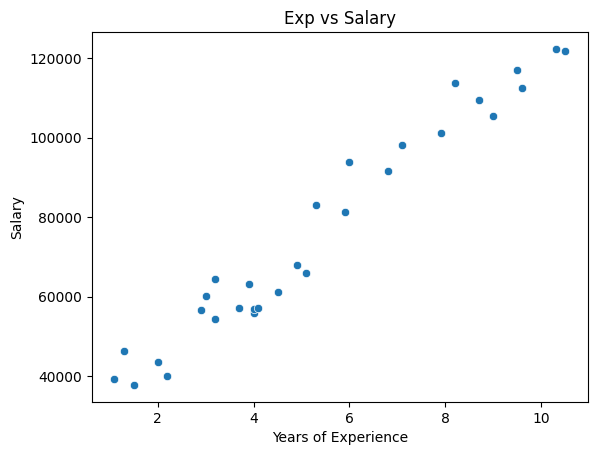

In [19]:
sns.scatterplot(x="YearsExperience",y="Salary",data=df)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Exp vs Salary")
plt.show()

In [20]:
# Splot INput & Output
X = df[["YearsExperience"]] # Independent variable
y = df["Salary"] # Dependent variable

In [23]:
# Train-Test split 80% training | 20% testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [24]:
# Trian Linear Regression Model 
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
# check model paramater
print('Slope (m): ',model.coef_)
print("Intercept (b) : ",model.intercept_)

Slope (m):  [9423.81532303]
Intercept (b) :  25321.583011776813


In [49]:
 Final Eqn: salary = 9423.82 * Experience + 25321.58
Every 1 Year of exp increse salary by (Rs 9,423)
Base salary (0 Exp) = RS 25,321

In [27]:
# Salary=m×Experience+c
y_pred = model.predict(X_test)

In [28]:
# Evaluate Model Performance
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [29]:
print("R2 Score : ",r2_score(y_test,y_pred))
print("MAE :",mean_absolute_error(y_test,y_pred))
print("MSE :",mean_squared_error(y_test,y_pred))

R2 Score :  0.9024461774180497
MAE : 6286.453830757749
MSE : 49830096.85590839


MAE = Rs 6,286 On avg, predication error is Rs6k
Acceptable for salary predication 

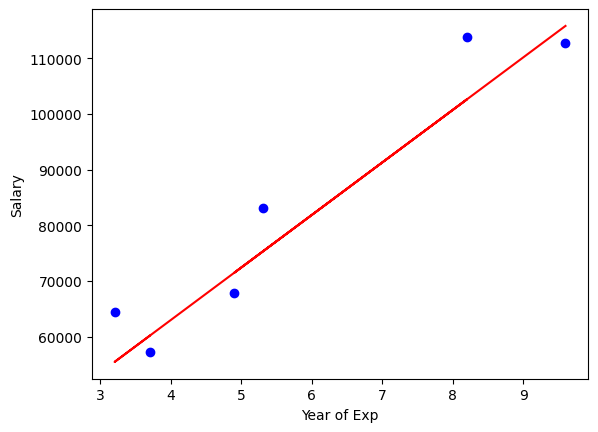

In [32]:
plt.scatter(X_test,y_test,color = "blue",label="Actual Salary")
plt.plot(X_test,y_pred,color = "red",label="predicated Salary")
plt.xlabel("Year of Exp")
plt.ylabel("Salary")
plt.show()

In [46]:
experience = [[1.5]]
predict_salary = model.predict(experience)
print("Predicated Salary :", predict_salary[0])

Predicated Salary : 39457.30599632328


C:\Users\Ritikyadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [41]:
# check Residuals 
residual = y_test - y_pred
residual

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64

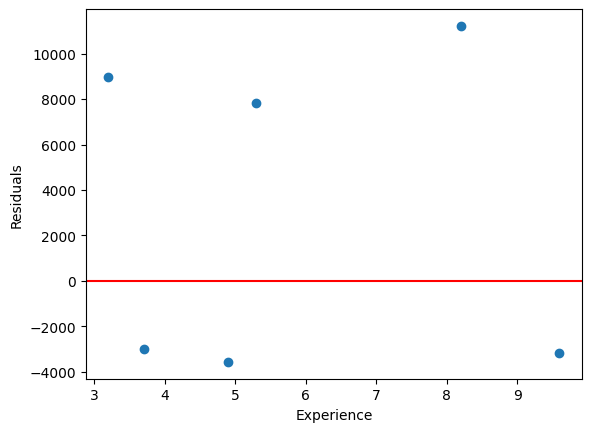

In [42]:
plt.scatter(X_test,residual)
plt.axhline(0,color="red")
plt.xlabel("Experience")
plt.ylabel("Residuals")
plt.show()

In [43]:
# Train vs Test score (Overfitting Check)
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print("Train Score: ",train_score)
print("Test Score: ",test_score)

Train Score:  0.9645401573418146
Test Score:  0.9024461774180497


In [45]:
model.predict([[2]])
model.predict([[10]])

C:\Users\Ritikyadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Ritikyadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([119559.73624209])